# Does Hosting the Olympics Improve Medal Performance?

## Project Inspiration
The Olympic Games are not only the world’s largest sporting event but also a stage where national pride and athletic performance intersect. Whilst watching the Olympics this year, I was struck by how well Japan were doing. As they were the host nation of this Olympics, it got me thinking: Does hosting the Olympics improve performance in the medals table? A recurring observation is that host nations often perform exceptionally well in the medals table. This raises an important question: **Does hosting the Olympics actually improve a country’s medal performance, or is it just a coincidence?**

## Objectives
- **Investigate** historical Olympic data to compare host nations’ performance before, during, and after hosting.  
- **Explore** trends in medal counts using statistical analysis and visualizations.  
- **Evaluate** whether hosting provides a measurable "home advantage" in the overall medals table.  

## Approach
This project focuses on **exploratory data analysis (EDA)** and **statistical testing** using Olympic datasets, including data from the Tokyo Olympics. Visual storytelling will be central, leveraging:
- **Matplotlib & Seaborn** for static plots

The goal is not only to analyze medal performance but also to **encourage deeper exploration** of Olympic data, sparking new questions and insights.  


## Dataset 1: 120 years of Olympic history

This dataset contains detailed information about Olympic athletes, events, and outcomes across multiple Games. Below is an explanation of each column for better understanding:

1. **ID** – Unique identifier for each athlete.  
2. **Name** – Full name of the athlete.  
3. **Sex** – Gender of the athlete (`M` = Male, `F` = Female).  
4. **Age** – Age of the athlete (integer).  
5. **Height** – Athlete’s height in centimeters.  
6. **Weight** – Athlete’s weight in kilograms.  
7. **Team** – Name of the athlete’s team (may represent a nation, region, or combined team).  
8. **NOC** – National Olympic Committee 3-letter code representing the country or region.  
9. **Games** – Year and season of the Olympics (e.g., `2008 Summer`).  
10. **Year** – The year the Olympic Games took place (integer).  
11. **Season** – Whether the Games were `Summer` or `Winter`.  
12. **City** – Host city of the Games.  
13. **Sport** – General category of the sport (e.g., Athletics, Swimming).  
14. **Event** – Specific discipline or event within the sport (e.g., 100m sprint).  
15. **Medal** – Type of medal won (`Gold`, `Silver`, `Bronze`), or `NA` if no medal was awarded.  

Additionally, this dataset can be enriched using a **NOC-to-Region mapping file**, which links each `NOC` code to the corresponding country/region name (e.g., `USA → United States`, `CHN → China`). This helps provide clearer geographic and regional insights during analysis.

# Dataset 2: 2021 Olympics in Tokyo

This dataset provides detailed information about the **Tokyo 2020 Olympics (held in 2021)**, covering athletes, teams, coaches, and events. It serves as a complementary dataset to the historical Olympic records, focusing specifically on the most recent Games.  

## Contents
The dataset is structured into multiple files:  
- **Athletes.xlsx** – Information about over 11,000 athletes, including their names, countries, and disciplines.  
- **Coaches.xlsx** – Details of coaches, including the teams and athletes they supported.  
- **EntriesGender.xlsx** – Participation statistics broken down by gender across events and disciplines.  
- **Medals.xlsx** – Medal counts (Gold, Silver, Bronze) awarded to athletes and teams.  
- **Teams.xlsx** – Details of the 743 teams participating in the Games.  

## Coverage
- **Disciplines**: 47  
- **Teams**: 743  
- **Athletes**: 11,000+   

**Source**: Tokyo Olympics 2020 Website  

## For the 2021 dataset we will only be using the Medals.xlsx

## 1) Importing Libraries

In [2]:
import os
os.chdir('C:/Users/phunh.DESKTOP-8S8LTG6/Desktop/Portfolio_projects/Tokyo_olympic')

In [48]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
pd.set_option("display.max_colwidth", None)

In [4]:
athlete_events = pd.read_csv('Data/athlete_events.csv')
noc_regions = pd.read_csv('Data/noc_regions.csv')

merged_df = athlete_events.merge(noc_regions, how='left', on='NOC')
merged_df.to_csv('Data/athlete_events_with_regions.csv', index=False)

In [5]:
merged_df.head(10)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN
5,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",NaN,Netherlands,NaN
6,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN
7,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",NaN,Netherlands,NaN
8,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN
9,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,"Speed Skating Women's 1,000 metres",NaN,Netherlands,NaN


In [6]:
merged_df = merged_df.query("Season == 'Summer'")  # Filter for Summer Olympics only

## 2) Initial Data Inspections

In [7]:
medals_df = pd.read_excel('Data/Medals.xlsx')

c:\Users\phunh.DESKTOP-8S8LTG6\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [8]:
medals_df.head()

,Rank,Team/NOC,Gold,Silver,Bronze,Total,Rank by Total
0,1,United States of America,39,41,33,113,1
1,2,People's Republic of China,38,32,18,88,2
2,3,Japan,27,14,17,58,5
3,4,Great Britain,22,21,22,65,4
4,5,ROC,20,28,23,71,3


## 3) Data Imputation 

In [9]:
merged_df.duplicated().sum()

1385

In [10]:
merged_df[merged_df.duplicated(keep=False)].head(20)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
1251,704,Dsir Antoine Acket,M,27.0,NaN,NaN,Belgium,BEL,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN,Belgium,NaN
1252,704,Dsir Antoine Acket,M,27.0,NaN,NaN,Belgium,BEL,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN,Belgium,NaN
4281,2449,William Truman Aldrich,M,48.0,NaN,NaN,United States,USA,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Drawings And Water Colors",NaN,USA,NaN
4282,2449,William Truman Aldrich,M,48.0,NaN,NaN,United States,USA,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Drawings And Water Colors",NaN,USA,NaN
4283,2449,William Truman Aldrich,M,48.0,NaN,NaN,United States,USA,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Drawings And Water Colors",NaN,USA,NaN
4861,2777,Hermann Reinhard Alker,M,43.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Designs For Town Planning",NaN,Germany,NaN
4862,2777,Hermann Reinhard Alker,M,43.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Designs For Town Planning",NaN,Germany,NaN
4863,2777,Hermann Reinhard Alker,M,43.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Architectural Designs",NaN,Germany,NaN
4864,2777,Hermann Reinhard Alker,M,43.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Architectural Designs",NaN,Germany,NaN
4866,2777,Hermann Reinhard Alker,M,51.0,NaN,NaN,Germany,GER,1936 Summer,1936,Summer,Berlin,Art Competitions,"Art Competitions Mixed Architecture, Unknown Event",NaN,Germany,NaN


In [11]:
merged_df = merged_df.drop_duplicates()

In [12]:
group_means = merged_df.groupby(['region', 'Sex', 'Sport'])[['Height', 'Weight']].transform('mean')

In [13]:
merged_df['Height'] = merged_df['Height'].fillna(group_means['Height'])
merged_df['Weight'] = merged_df['Weight'].fillna(group_means['Weight'])

In [14]:
print("Remaining missing values in Height:", merged_df['Height'].isna().sum())
print("Remaining missing values in Weight:", merged_df['Weight'].isna().sum())

Remaining missing values in Height: 2718
Remaining missing values in Weight: 3011


In [15]:
sport_means = merged_df.groupby(['Sex', 'Sport'])[['Height', 'Weight']].transform('mean')
merged_df['Height'] = merged_df['Height'].fillna(sport_means['Height'])
merged_df['Weight'] = merged_df['Weight'].fillna(sport_means['Weight'])

In [16]:
print("Remaining missing values in Height:", merged_df['Height'].isna().sum())
print("Remaining missing values in Weight:", merged_df['Weight'].isna().sum())

Remaining missing values in Height: 55
Remaining missing values in Weight: 406


In [17]:
before_rows = merged_df.shape[0]
merged_df = merged_df.dropna(subset=['Height', 'Weight'])
after_rows = merged_df.shape[0]

print(f"Rows before: {before_rows}")
print(f"Rows after:  {after_rows}")
print(f"Dropped:     {before_rows - after_rows}")

Rows before: 221167
Rows after:  220761
Dropped:     406


In [18]:
merged_df.isna().sum()

ID             0
Name           0
Sex            0
Age         8960
Height         0
Weight         0
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     186817
region       370
notes     216364
dtype: int64

In [19]:
age_means = merged_df.groupby(['region','Sex','Sport'])['Age'].transform('mean')
merged_df['Age'] = merged_df['Age'].fillna(age_means)

In [20]:
merged_df = merged_df.dropna(subset=['Age'])

In [21]:
merged_df = merged_df.drop(columns=['notes'])

In [22]:
# Build a mapping from existing rows
noc_region_map = merged_df.dropna(subset=['region']).drop_duplicates(subset=['NOC'])[['NOC','region']]
noc_region_dict = dict(zip(noc_region_map['NOC'], noc_region_map['region']))

# Fill missing region based on NOC
merged_df['region'] = merged_df.apply(
    lambda r: noc_region_dict.get(r['NOC'], 'Unknown') if pd.isna(r['region']) else r['region'],
    axis=1
)

print("Remaining missing regions:", merged_df['region'].isna().sum())

Remaining missing regions: 0


## 4) Exploratory Data Analysis

### Univariate Analysis

📊 Analysis for: Age
count    220561.000000
mean         25.593598
std           6.367616
min          10.000000
1%           15.000000
5%           17.333333
25%          21.000000
50%          25.000000
75%          28.000000
95%          37.000000
99%          48.000000
max          97.000000
Name: Age, dtype: float64
Skewness: 1.5646268828259124
Kurtosis: 4.913381773565851


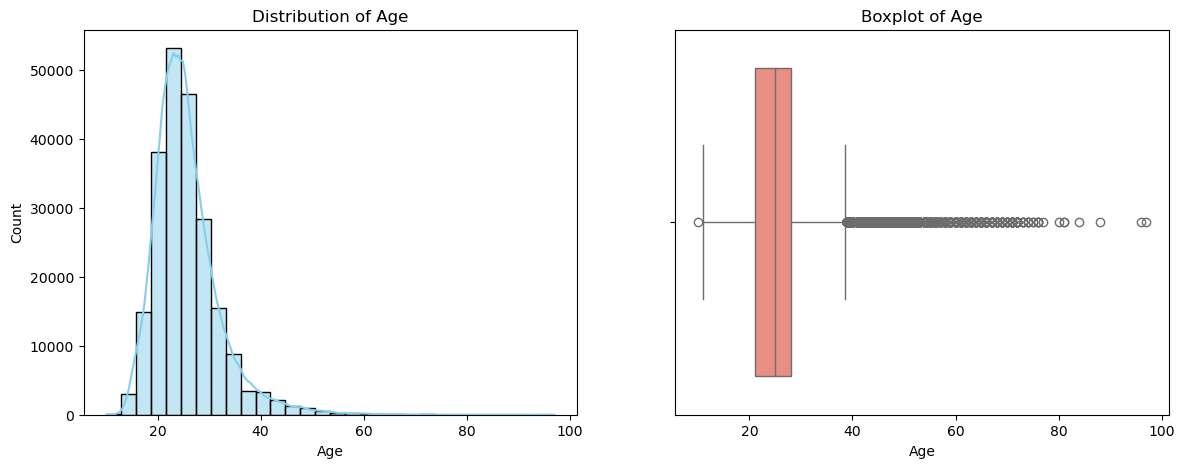

📊 Analysis for: Height
count    220561.000000
mean        175.758541
std          10.240271
min         127.000000
1%          150.617886
5%          159.000000
25%         169.000000
50%         176.000000
75%         182.212766
95%         192.000000
99%         200.000000
max         226.000000
Name: Height, dtype: float64
Skewness: -0.05513083789198793
Kurtosis: 0.36072146238894076


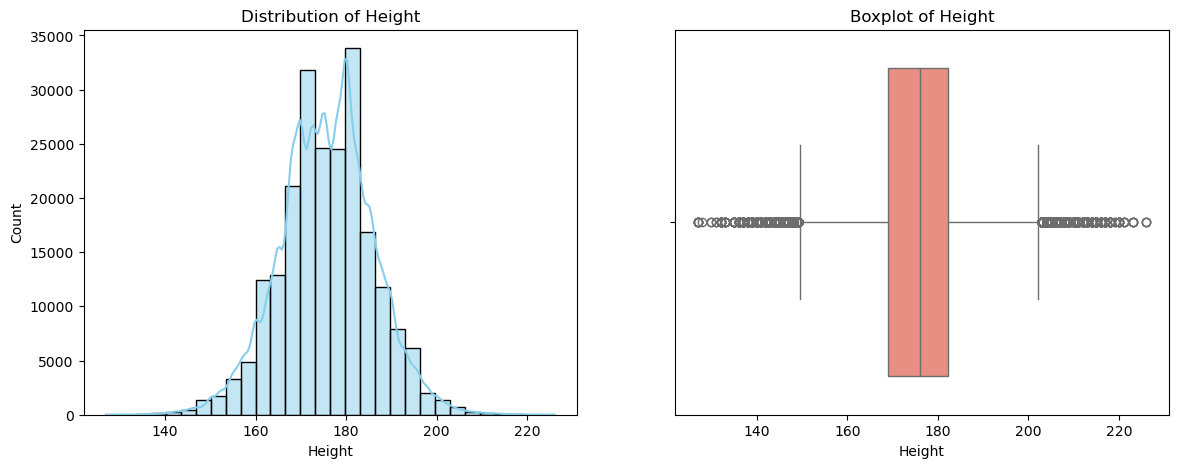

📊 Analysis for: Weight
count    220561.000000
mean         71.254823
std          13.679357
min          25.000000
1%           43.000000
5%           50.000000
25%          62.000000
50%          71.000000
75%          79.000000
95%          94.000000
99%         112.000000
max         214.000000
Name: Weight, dtype: float64
Skewness: 0.7157586372746473
Kurtosis: 2.43653429659941


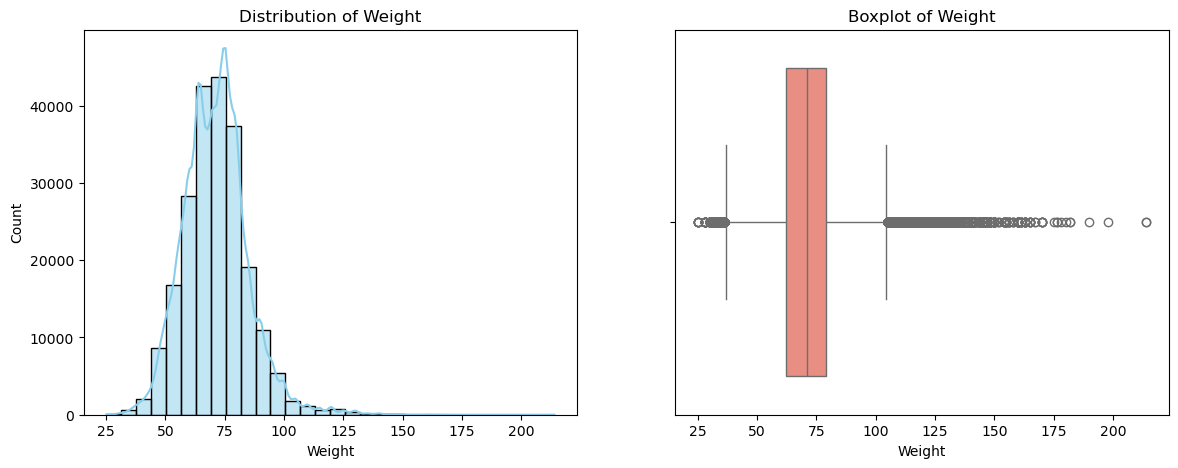

In [23]:
num_cols = ['Age', 'Height', 'Weight']

for col in num_cols:
    print("="*60)
    print(f"📊 Analysis for: {col}")
    print(merged_df[col].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
    print("Skewness:", merged_df[col].skew())
    print("Kurtosis:", merged_df[col].kurt())
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.histplot(merged_df[col], bins=30, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f"Distribution of {col}")
    
    sns.boxplot(x=merged_df[col], ax=axes[1], color='salmon')
    axes[1].set_title(f"Boxplot of {col}")
    
    plt.show()

📊 Analysis for: Sex
Sex
M    161524
F     59037
Name: count, dtype: int64
Unique categories: 2


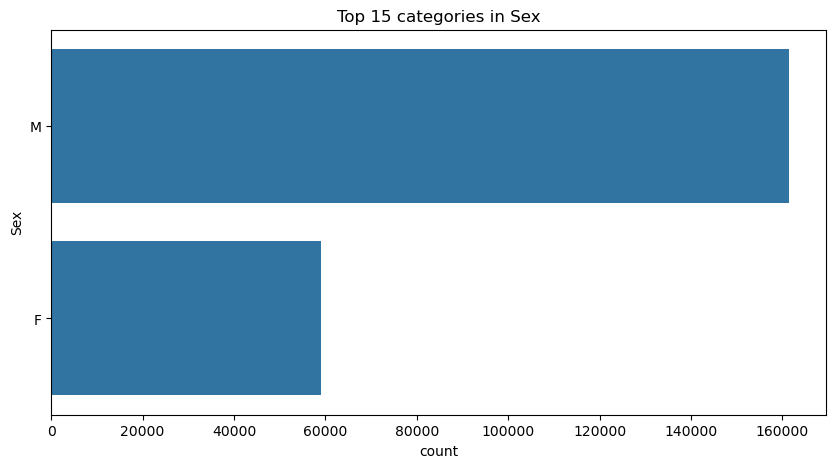

📊 Analysis for: Medal
Medal
NaN       186639
Gold       11404
Bronze     11355
Silver     11163
Name: count, dtype: int64
Unique categories: 3


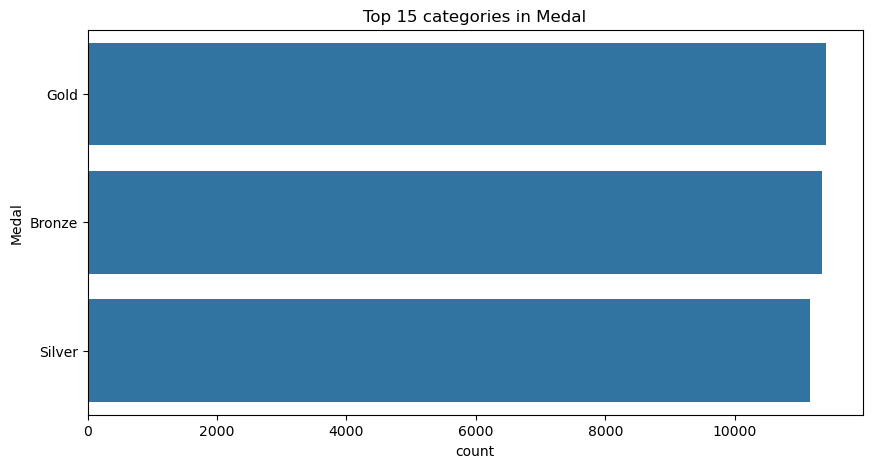

📊 Analysis for: Sport
Sport
Athletics        38624
Gymnastics       26663
Swimming         23195
Shooting         11433
Cycling          10817
Fencing          10735
Rowing           10595
Wrestling         7152
Football          6734
Sailing           6547
Equestrianism     6343
Canoeing          6171
Boxing            6045
Hockey            5417
Basketball        4499
Name: count, dtype: int64
Unique categories: 43


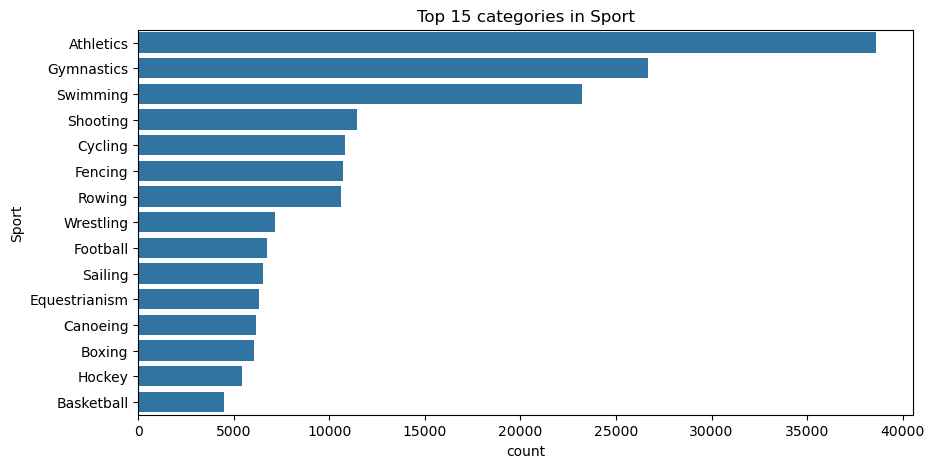

📊 Analysis for: Event
Event
Football Men's Football                   5722
Hockey Men's Hockey                       3958
Water Polo Men's Water Polo               3356
Basketball Men's Basketball               3243
Cycling Men's Road Race, Individual       2941
Gymnastics Men's Individual All-Around    2494
Rowing Men's Coxed Eights                 2423
Gymnastics Men's Team All-Around          2405
Handball Men's Handball                   2264
Athletics Men's Marathon                  2093
Gymnastics Men's Parallel Bars            2043
Gymnastics Men's Horizontal Bar           2035
Gymnastics Men's Pommelled Horse          2026
Gymnastics Men's Rings                    2015
Athletics Men's 100 metres                1936
Name: count, dtype: int64
Unique categories: 639


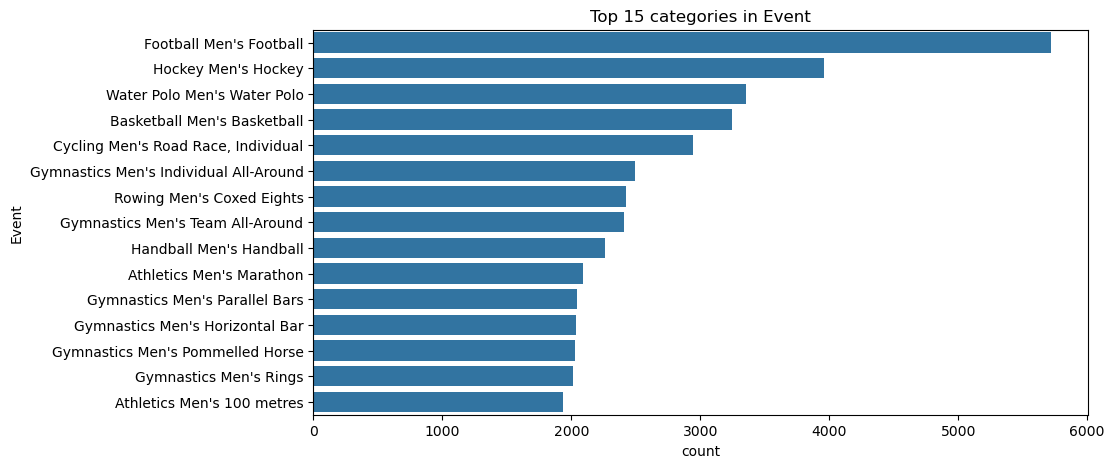

📊 Analysis for: Season
Season
Summer    220561
Name: count, dtype: int64
Unique categories: 1


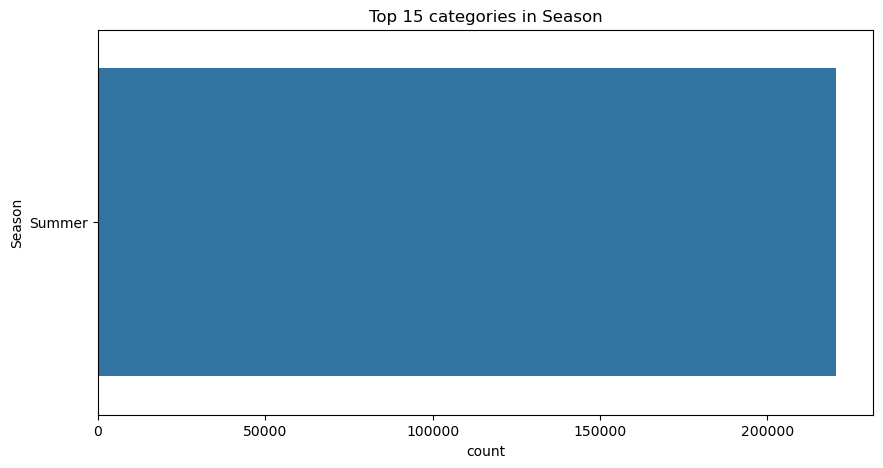

📊 Analysis for: region
region
USA            14744
Germany        12267
UK             10667
France         10368
Russia          8854
Italy           8164
Australia       7176
Canada          6802
Japan           6311
Hungary         6067
Sweden          6025
Netherlands     5091
China           4995
Spain           4894
Poland          4794
Name: count, dtype: int64
Unique categories: 206


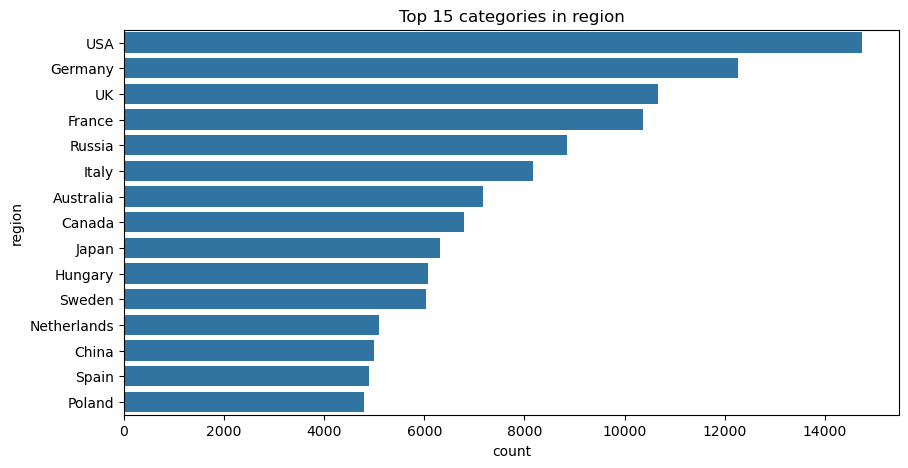

In [24]:
categorical_cols = ['Sex', 'Medal', 'Sport', 'Event', 'Season', 'region']

for col in categorical_cols:
    print("="*60)
    print(f"📊 Analysis for: {col}")
    print(merged_df[col].value_counts(dropna=False).head(15))  
    print("Unique categories:", merged_df[col].nunique())
    
    plt.figure(figsize=(10, 5))
    sns.countplot(data=merged_df, y=col, order=merged_df[col].value_counts().index[:15])
    plt.title(f"Top 15 categories in {col}")
    plt.show()


### Bivariate and Multi-variate Analysis

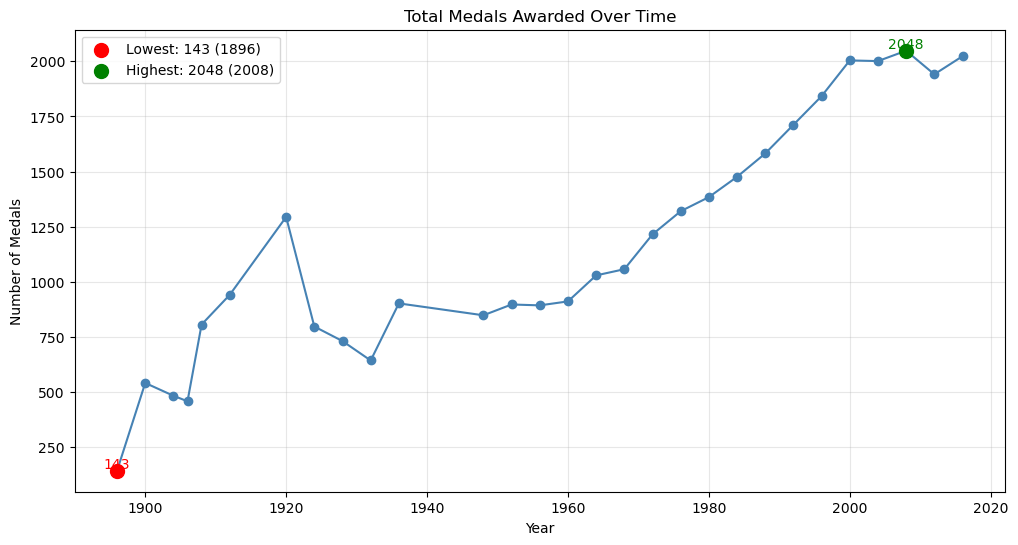

In [25]:
medals_over_time = merged_df.dropna(subset=['Medal']).groupby('Year')['Medal'].count()

min_year = medals_over_time.idxmin()
min_val = medals_over_time.min()
max_year = medals_over_time.idxmax()
max_val = medals_over_time.max()

plt.figure(figsize=(12,6))
plt.plot(medals_over_time.index, medals_over_time.values, marker='o', color='steelblue')

plt.scatter(min_year, min_val, color='red', s=100, zorder=5, label=f"Lowest: {min_val} ({min_year})")
plt.text(min_year, min_val+10, f"{min_val}", color='red', ha='center', fontsize=10)

plt.scatter(max_year, max_val, color='green', s=100, zorder=5, label=f"Highest: {max_val} ({max_year})")
plt.text(max_year, max_val+10, f"{max_val}", color='green', ha='center', fontsize=10)

plt.title("Total Medals Awarded Over Time")
plt.ylabel("Number of Medals")
plt.xlabel("Year")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [26]:
medals_df.head(10)

,Rank,Team/NOC,Gold,Silver,Bronze,Total,Rank by Total
0,1,United States of America,39,41,33,113,1
1,2,People's Republic of China,38,32,18,88,2
2,3,Japan,27,14,17,58,5
3,4,Great Britain,22,21,22,65,4
4,5,ROC,20,28,23,71,3
5,6,Australia,17,7,22,46,6
6,7,Netherlands,10,12,14,36,9
7,8,France,10,12,11,33,10
8,9,Germany,10,11,16,37,8
9,10,Italy,10,10,20,40,7


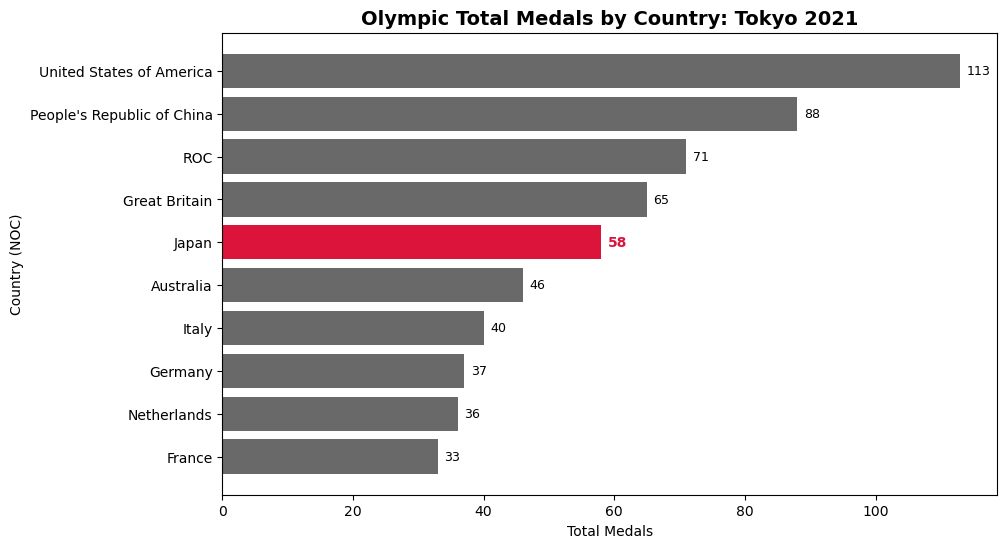

In [27]:
medals_by_noc = medals_df.groupby('Team/NOC')[['Gold','Silver','Bronze','Total']].sum().reset_index()
medals_by_noc = medals_by_noc.sort_values('Total', ascending=False)

topN = medals_by_noc.head(10)

japan_label = "Japan" 
colors = ["crimson" if x == japan_label else "dimgray" for x in topN['Team/NOC']]

plt.figure(figsize=(10,6))
bars = plt.barh(topN['Team/NOC'], topN['Total'], color=colors)

for i, (country, total) in enumerate(zip(topN['Team/NOC'], topN['Total'])):
    if country == japan_label:
        plt.text(total + 1, i, str(total), va='center', fontsize=10, color='crimson', weight='bold')
    else:
        plt.text(total + 1, i, str(total), va='center', fontsize=9, color='black')

plt.title("Olympic Total Medals by Country: Tokyo 2021", fontsize=14, weight='bold')
plt.xlabel("Total Medals")
plt.ylabel("Country (NOC)")

plt.gca().invert_yaxis()
plt.show()

We see a familiar top position with United States of America, China, Great Britain and Japan

c:\Users\phunh.DESKTOP-8S8LTG6\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127941 (\N{SPORTS MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


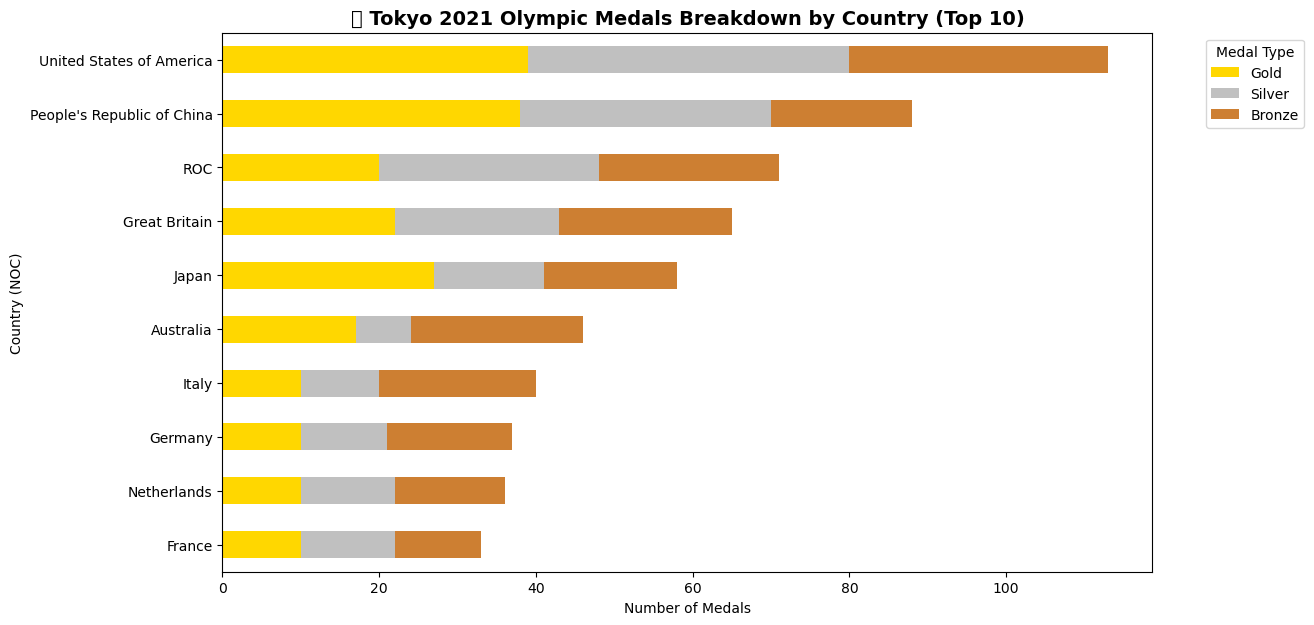

In [28]:
medals_by_noc = medals_df.groupby('Team/NOC')[['Gold','Silver','Bronze','Total']].sum().reset_index()
medals_by_noc = medals_by_noc.sort_values('Total', ascending=False)

top10 = medals_by_noc.head(10).set_index('Team/NOC')

top10[['Gold','Silver','Bronze']].plot(
    kind='barh',
    stacked=True,
    figsize=(12,7),
    color=['#FFD700', '#C0C0C0', '#CD7F32']  
)

plt.title("🏅 Tokyo 2021 Olympic Medals Breakdown by Country (Top 10)", fontsize=14, weight='bold')
plt.xlabel("Number of Medals")
plt.ylabel("Country (NOC)")
plt.legend(title="Medal Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().invert_yaxis() 
plt.show()

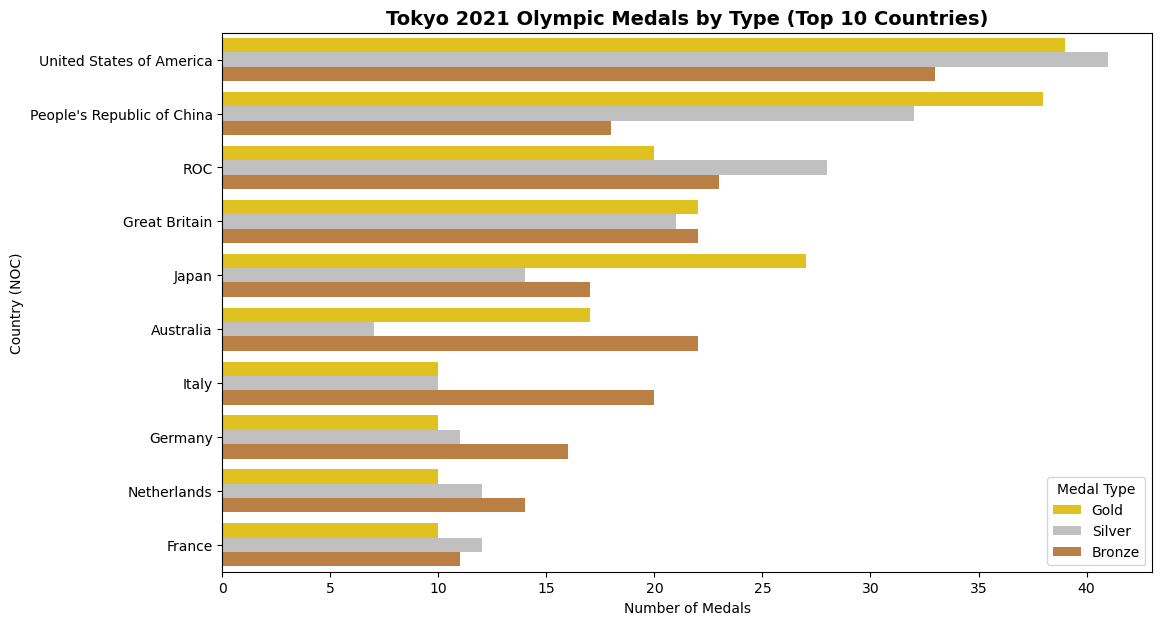

In [29]:
top10_long = top10[['Gold','Silver','Bronze']].reset_index().melt(id_vars='Team/NOC', var_name='Medal', value_name='Count')

plt.figure(figsize=(12,7))
sns.barplot(data=top10_long, x='Count', y='Team/NOC', hue='Medal',
            palette={'Gold':'#FFD700', 'Silver':'#C0C0C0', 'Bronze':'#CD7F32'})

plt.title("Tokyo 2021 Olympic Medals by Type (Top 10 Countries)", fontsize=14, weight='bold')
plt.xlabel("Number of Medals")
plt.ylabel("Country (NOC)")
plt.legend(title="Medal Type")
plt.show()

In [30]:
#Replacing the country name with common values
merged_df.replace('USA', "United States of America", inplace = True)
merged_df.replace('Tanzania', "United Republic of Tanzania", inplace = True)
merged_df.replace('Democratic Republic of Congo', "Democratic Republic of the Congo", inplace = True)
merged_df.replace('Congo', "Republic of the Congo", inplace = True)
merged_df.replace('Lao', "Laos", inplace = True)
merged_df.replace('Syrian Arab Republic', "Syria", inplace = True)
merged_df.replace('Serbia', "Republic of Serbia", inplace = True)
merged_df.replace('Czechia', "Czech Republic", inplace = True)
merged_df.replace('UAE', "United Arab Emirates", inplace = True)
merged_df.replace('UK', "United Kingdom", inplace = True)

medals_df.replace('Great Britain', "United Kingdom", inplace = True)
medals_df.replace("People's Republic of China", "China", inplace = True)
medals_df.replace("ROC", "Russia", inplace = True)


In [31]:
def host_country(col):
    if col == "Rio de Janeiro":
        return "Brazil"
    elif col == "London":
        return "United Kingdom"
    elif col == "Beijing":
        return  "China"
    elif col == "Athina":
        return  "Greece"
    elif col == "Sydney" or col == "Melbourne":
        return  "Australia"
    elif col == "Atlanta" or col == "Los Angeles" or col == "St. Louis":
        return  "United States of America"
    elif col == "Barcelona":
        return  "Spain"
    elif col == "Seoul":
        return  "South Korea"
    elif col == "Moskva":
        return  "Russia"
    elif col == "Montreal":
        return  "Canada"
    elif col == "Munich" or col == "Berlin":
        return  "Germany"
    elif col == "Mexico City":
        return  "Mexico"
    elif col == "Tokyo":
        return  "Japan"
    elif col == "Roma":
        return  "Italy"
    elif col == "Paris":
        return  "France"
    elif col == "Helsinki":
        return  "Finland"
    elif col == "Amsterdam":
        return  "Netherlands"
    elif col == "Antwerpen":
        return  "Belgium"
    elif col == "Stockholm":
        return  "Sweden"
    else:
        return "Other"


# Applying this function

merged_df['Host_Country'] = merged_df['City'].apply(host_country)

In [32]:
df_new = merged_df.groupby(['Year','Host_Country','region','Medal'])['Medal'].count().unstack().fillna(0).astype(int).reset_index()

df_new['Is_Host'] = np.where(df_new['Host_Country'] == df_new['region'],1,0)
df_new['Total Medals'] = df_new['Bronze'] + df_new['Silver'] + df_new['Gold']

In [33]:
df_new

Medal,Year,Host_Country,region,Bronze,Gold,Silver,Is_Host,Total Medals
0,1896,Greece,Australia,1,2,0,0,3
1,1896,Greece,Austria,2,2,1,0,5
2,1896,Greece,Denmark,3,1,2,0,6
3,1896,Greece,France,2,5,4,0,11
4,1896,Greece,Germany,2,25,5,0,32
...,...,...,...,...,...,...,...,...
1263,2016,Brazil,Bahrain,0,1,1,0,2
1264,2016,Brazil,Grenada,0,0,1,0,1
1265,2016,Brazil,Fiji,0,13,0,0,13
1266,2016,Brazil,Jordan,0,1,0,0,1


In [34]:
# Preparing to add 2021 data to our historic df

merged_df_full = medals_df[['Team/NOC', "Gold", "Silver", "Bronze"]]
merged_df_full['Total Medals'] = merged_df_full[["Gold", "Silver", "Bronze"]].sum(axis=1)
merged_df_full['Year'] = 2021

merged_df_full['Is_Host'] = np.where(merged_df_full['Team/NOC'] == 'Japan',1,0)
merged_df_full['Host_Country'] = 'Japan'
merged_df_full = merged_df_full.rename(columns={'Team/NOC':'region'})

df_new = pd.concat([df_new, merged_df_full], ignore_index=True)

# Removing Russia as many Olympic games were competed in as the Soviet Union, containing several modern day nations

df_new = df_new.query("region != 'Russia' & region != 'ROC'")

C:\Users\phunh.DESKTOP-8S8LTG6\AppData\Local\Temp\ipykernel_22008\1844927217.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_full['Total Medals'] = merged_df_full[["Gold", "Silver", "Bronze"]].sum(axis=1)
C:\Users\phunh.DESKTOP-8S8LTG6\AppData\Local\Temp\ipykernel_22008\1844927217.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_full['Year'] = 2021


In [35]:
merged_df_full.head()

,region,Gold,Silver,Bronze,Total Medals,Year,Is_Host,Host_Country
0,United States of America,39,41,33,113,2021,0,Japan
1,China,38,32,18,88,2021,0,Japan
2,Japan,27,14,17,58,2021,1,Japan
3,United Kingdom,22,21,22,65,2021,0,Japan
4,Russia,20,28,23,71,2021,0,Japan


### For this project we will only focus on summer olymics

I'll winden my view. Lets look at the leaderboard for all the summer olymics

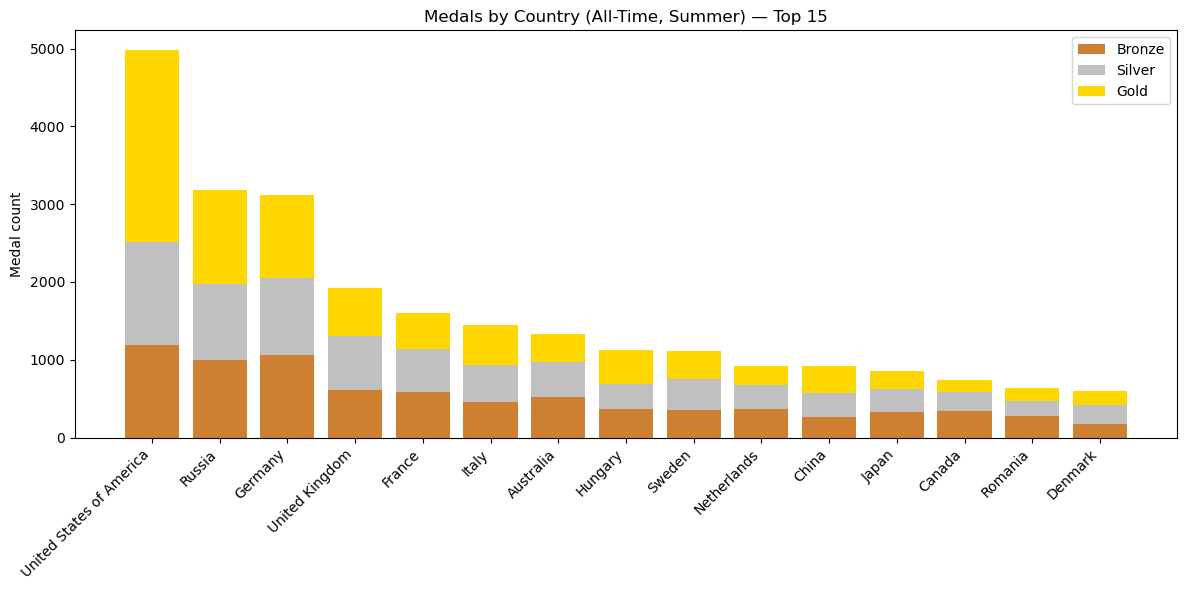

In [36]:
medals_ath = (
    merged_df.loc[merged_df["Medal"].notna(), ["region", "Medal"]]
              .groupby(["region", "Medal"])
              .size()
              .unstack(fill_value=0)
              .reindex(columns=["Bronze", "Silver", "Gold"], fill_value=0)
)
medals_ath["Total"] = medals_ath[["Gold","Silver","Bronze"]].sum(axis=1)
top15 = medals_ath.sort_values("Total", ascending=False).head(15)

# Plot with correct medal colors
x = np.arange(len(top15))
labels = top15.index.tolist()

plt.figure(figsize=(12, 6))
plt.bar(x, top15["Bronze"], label="Bronze", color="#CD7F32")
plt.bar(x, top15["Silver"], bottom=top15["Bronze"], label="Silver", color="silver")
plt.bar(x, top15["Gold"],   bottom=top15["Bronze"]+top15["Silver"], label="Gold", color="gold")

plt.title("Medals by Country (All-Time, Summer) — Top 15")
plt.ylabel("Medal count")
plt.xticks(x, labels, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


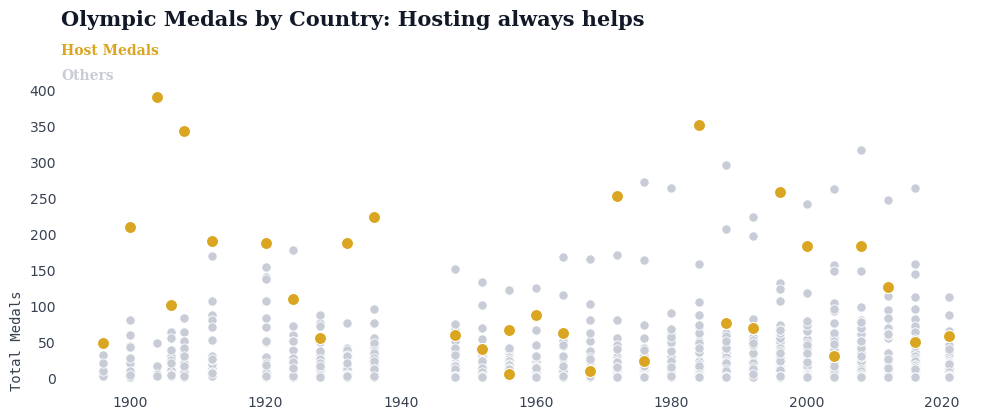

In [37]:
HIST_COLOR   = "#C8CCD7"  # non-host points
HOST_COLOR   = "#DAA520"  # host points (gold)
TITLE_COLOR  = "#111827"
TICK_COLOR   = "#374151"

fig, ax = plt.subplots(1, 1, figsize=(12, 4))

sns.scatterplot(
    data=df_new.query("Is_Host == 0"),
    x="Year", y="Total Medals",
    s=45, ec="white", linewidth=0.6,
    color=HIST_COLOR, ax=ax
)
sns.scatterplot(
    data=df_new.query("Is_Host == 1"),
    x="Year", y="Total Medals",
    s=75, ec="white", linewidth=0.8,
    color=HOST_COLOR, ax=ax
)

Xstart, Xend = ax.get_xlim()
Ystart, Yend = ax.get_ylim()

ax.tick_params(axis='both', which='both', length=0, labelcolor=TICK_COLOR)
ax.set_ylabel("Total Medals", fontfamily='monospace', loc='bottom', color=TICK_COLOR)
ax.set_xlabel("")
ax.set_axisbelow(True)

for s in ['top','right','bottom','left']:
    ax.spines[s].set_visible(False)

ax.text(Xstart, Yend + 80,
        'Olympic Medals by Country: Hosting always helps',
        fontsize=15, fontweight='bold', fontfamily='serif', color=TITLE_COLOR)
ax.text(Xstart, Yend + 40,
        'Host Medals', fontsize=10, fontweight='bold',
        fontfamily='serif', color=HOST_COLOR)
ax.text(Xstart, Yend + 5,
        'Others', fontsize=10, fontweight='bold',
        fontfamily='serif', color=HIST_COLOR)

plt.show()

We see that the majority of times, the hosting nations seem to obtain higher level of total medals compared to other nations. But we must keep in mind that it is often rich nations that hosts the games. Therefore, they are already likely to achieve better results. 

Now lets shift our focus to nations who have hosted the games

Text(0, 21.95, 'Average')

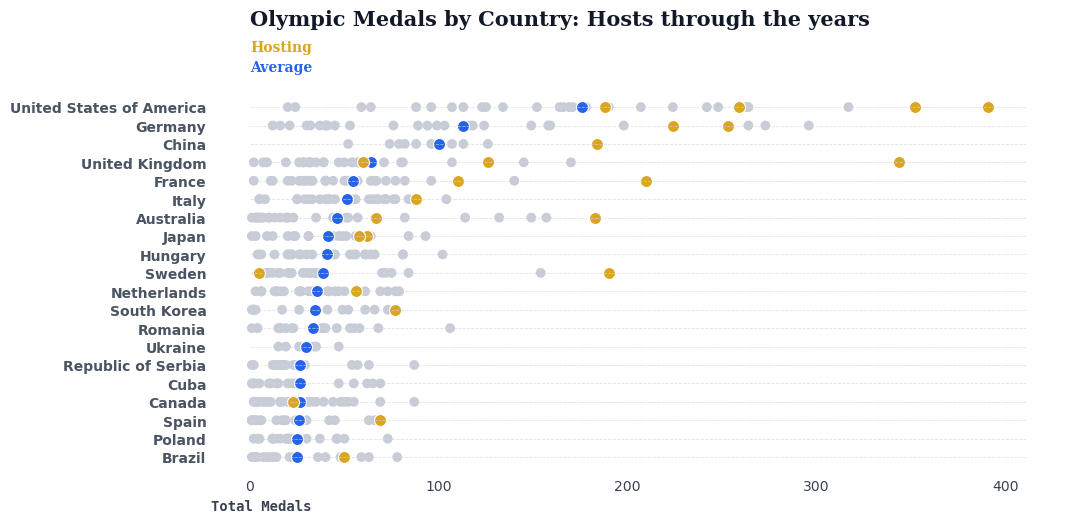

In [38]:
# Palette
HIST_COLOR = "#C8CCD7"   # historic points (light grey-blue)
MEAN_COLOR = "#2563EB"   # average points (blue)
HOST_COLOR = "#DAA520"   # hosting points (gold)

TITLE_COLOR = "#111827"
SUB_HOST_COLOR = HOST_COLOR
SUB_MEAN_COLOR = MEAN_COLOR
TICK_COLOR = "#374151"
GRID_COLOR = "#D1D5DB"

fig, ax = plt.subplots(1, 1, figsize=(11, 5))

# top 20
top_list_ = (
    df_new.groupby('region')['Total Medals'].mean()
          .sort_values(ascending=False)
          .reset_index()[:20]
          .sort_values(by='Total Medals', ascending=True)
)

plot = 1
for country in top_list_['region']:
    mean = df_new[df_new['region'] == country].groupby('region')['Total Medals'].mean()
    # historic scores
    sns.scatterplot(
        data=df_new[df_new['region'] == country],
        y=plot, x='Total Medals',
        color=HIST_COLOR, s=50, ax=ax, edgecolor="none"
    )
    # mean score
    sns.scatterplot(
        data=df_new[df_new['region'] == country],
        y=plot, x=mean,
        color=MEAN_COLOR, ec='white', linewidth=0.8, s=75, ax=ax
    )
    # hosting score
    sns.scatterplot(
        data=df_new[(df_new['region'] == country) & (df_new['Is_Host'] == 1)],
        y=plot, x='Total Medals',
        color=HOST_COLOR, ec='white', linewidth=0.8, s=75, ax=ax
    )
    plot += 1

Xstart, Xend = ax.get_xlim()
Ystart, Yend = ax.get_ylim()

ax.set_yticks(top_list_.index + 1)
ax.set_yticklabels(
    top_list_['region'][::-1],
    fontdict={'horizontalalignment': 'right', 'fontweight': 'semibold'},
    color=TICK_COLOR, alpha=0.9
)
ax.tick_params(axis='both', which='both', length=0, labelcolor=TICK_COLOR)
ax.set_xlabel("Total Medals", fontfamily='monospace', fontweight='semibold',
              loc='left', color=TICK_COLOR)

# subtle gridlines
ax.hlines(y=top_list_.index + 1, xmin=0, xmax=Xend,
          color=GRID_COLOR, alpha=0.7, linewidth=.6, linestyles='--')
ax.set_axisbelow(True)

for s in ['top', 'right', 'bottom', 'left']:
    ax.spines[s].set_visible(False)

# title and subtitles (same placement, new styling)
ax.text(0, Yend + 3.5,
        'Olympic Medals by Country: Hosts through the years',
        fontsize=15, fontweight='bold', fontfamily='serif', color=TITLE_COLOR)

ax.text(0, Yend + 2.1,
        'Hosting', fontsize=10, fontweight='bold',
        fontfamily='serif', color=SUB_HOST_COLOR)

ax.text(0, Yend + 1.0,
        'Average', fontsize=10, fontweight='bold',
        fontfamily='serif', color=SUB_MEAN_COLOR)

A fantastic plot. It shows us information about each nations historic performances (grey dots), average performance (blue dots) and their performance when hosting the olympics (red dots). It is clear that when they host olympics they perform better.

In [39]:
sample = df_new.groupby(['region','Is_Host'])['Gold'].mean().unstack().dropna()
sample = sample.rename(columns={0 : "Not Hosting", 1 : "Hosting"})
sample = sample.reset_index().query("region == 'Japan' | region == 'Brazil' | region == 'United Kingdom' | region == 'China' | region == 'Greece' ").set_index('region')

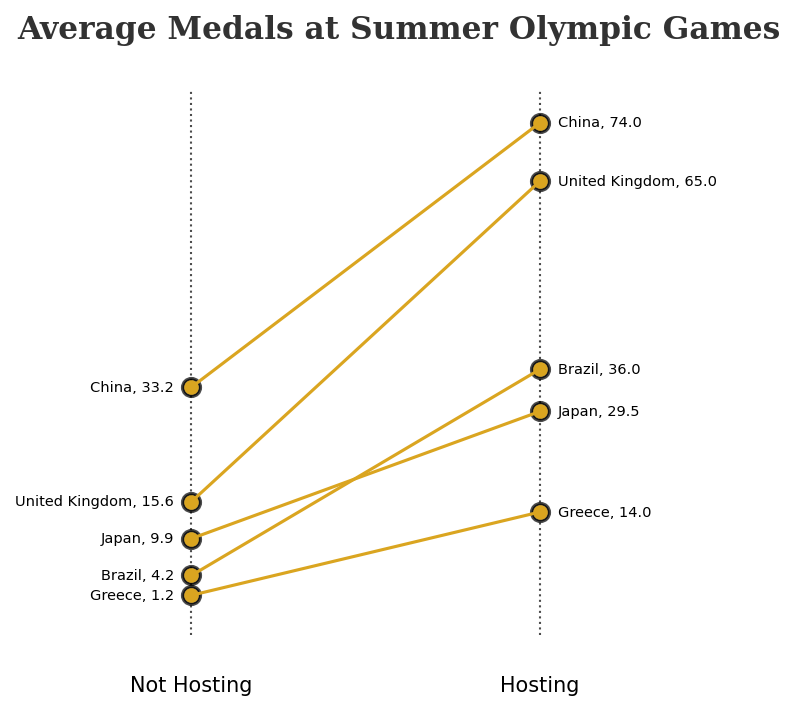

In [40]:
import matplotlib.lines as mlines

low_c = "#2563EB"
high_c = "#DAA520"

left_label = [str(c) + ', '+ str(round(y)) for c, y in zip(sample.index, sample['Not Hosting'])]
right_label = [str(c) + ', '+ str(round(y)) for c, y in zip(sample.index, sample['Hosting'])]
klass = [low_c if (y1-y2) < 0 else high_c for y1, y2 in zip(sample['Not Hosting'], sample['Hosting'])]

# draw line
# https://stackoverflow.com/questions/36470343/how-to-draw-a-line-with-matplotlib/36479941
def newline(p1, p2, color='black'):
    ax = plt.gca()
    l = mlines.Line2D([p1[0],p2[0]], [p1[1],p2[1]], color=low_c if p1[1]-p2[1] > 0 else high_c, marker='o', markersize=6)
    ax.add_line(l)
    return l

fig, ax = plt.subplots(1,1,figsize=(6,5), dpi= 150)

ax.vlines(x=1, ymin=-5, ymax=100, color='black', alpha=0.7, linewidth=1, linestyles='dotted')
ax.vlines(x=3, ymin=-5, ymax=100, color='black', alpha=0.7, linewidth=1, linestyles='dotted')

# Points
ax.scatter(y=sample['Not Hosting'], x=np.repeat(1, sample.shape[0]), s=75,linewidth=1.5, color='black', alpha=0.7)
ax.scatter(y=sample['Hosting'], x=np.repeat(3, sample.shape[0]), s=75, linewidth=1.5,color='black', alpha=0.7)

# Line Segments and Annotation
for p1, p2, c in zip(sample['Not Hosting'], sample['Hosting'], sample.index):
    newline([1,p1], [3,p2])
    ax.text(1-0.1, p1, c + ', ' + str(round(p1,1)), horizontalalignment='right', verticalalignment='center', fontdict={'size':7})
    ax.text(3+0.1, p2, c + ', ' + str(round(p2,1)), horizontalalignment='left', verticalalignment='center', fontdict={'size':7})


ax.text(0,87,"Average Medals at Summer Olympic Games", fontsize=15,fontweight='bold',fontfamily='serif',color='#323232')

ax.set(xlim=(0,4), ylim=(-10,sample.max().max()+5), ylabel='') #ylim=(), 
ax.set_xticks([1,3])
ax.set_xticklabels(["Not Hosting", "Hosting"],fontsize=10)
#ax.xaxis.tick_top()

for s in ["top","right","left","bottom"]:
    ax.spines[s].set_visible(False)
    
ax.tick_params(axis='both',which='both',length=0,labelleft=False) 
plt.rcParams["font.family"] = "monospace"

plt.show()


We see that in the sample all the nations drastically improved their total medel average when hosting 

Lets look at medals overtime for some host nations. We will go deeper into the United Kingdom and Japan, as I have mention that i am quite impressed by their performance in the Tokyo Olympics

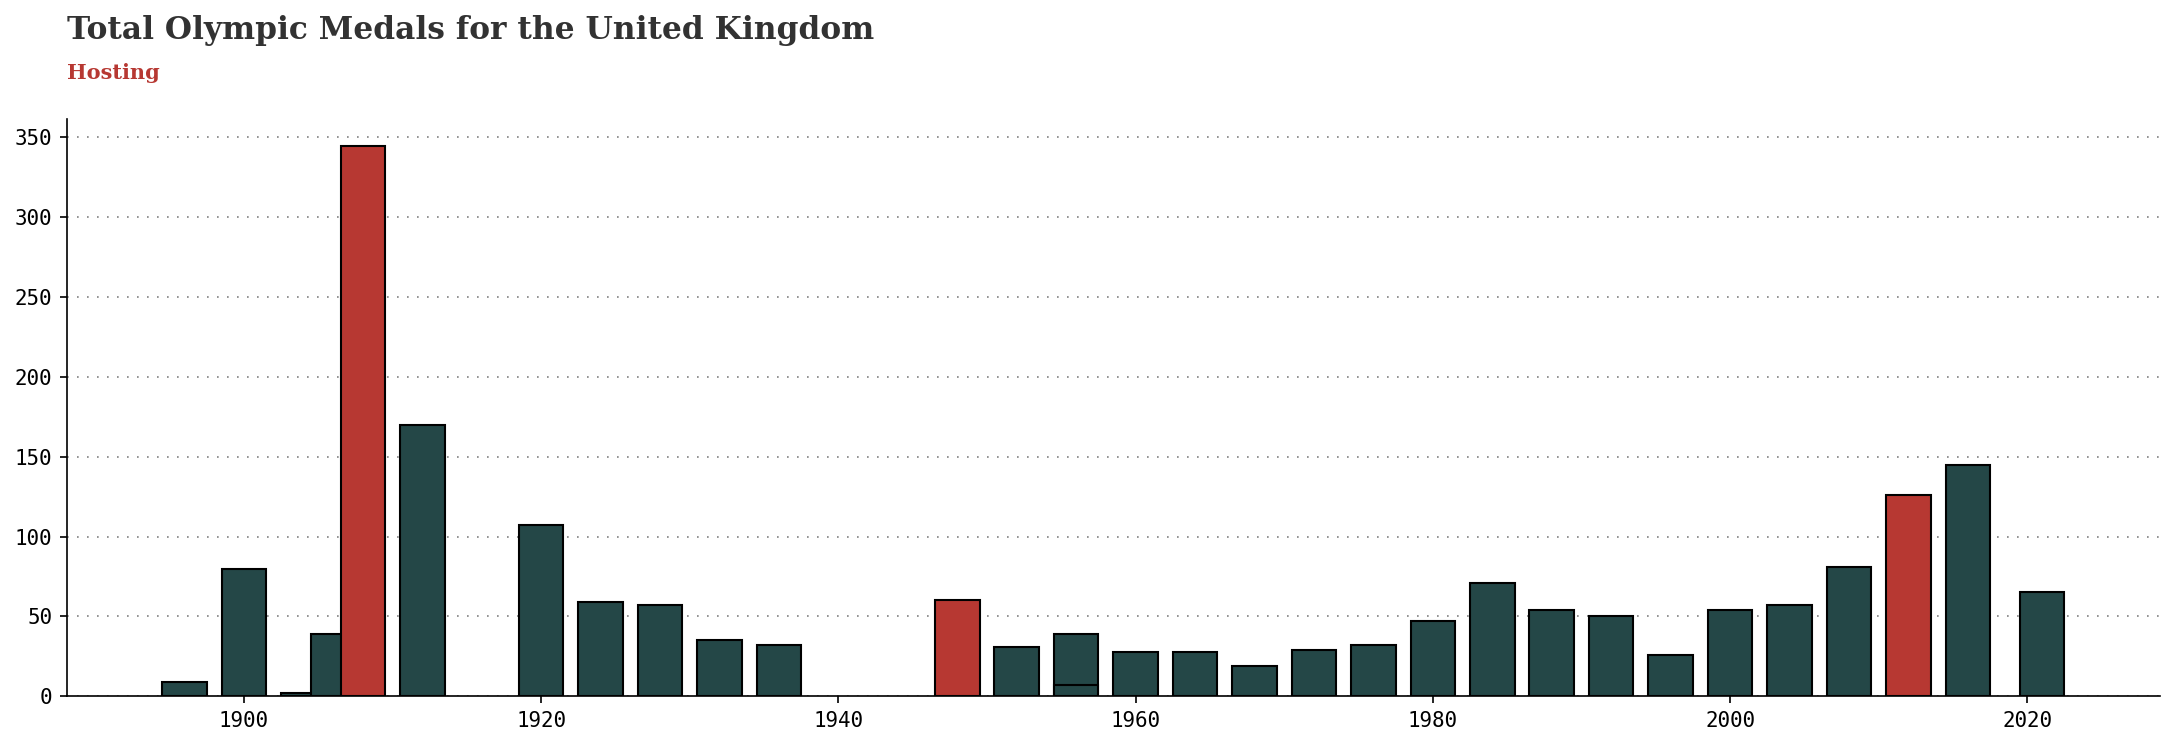

In [41]:
temp = df_new.query("region == 'United Kingdom'")


fig, ax = plt.subplots(1, 1, figsize=(18, 5), dpi=150,)

color = ['#B73832' if i == 1 else '#244747' for i in temp['Is_Host']]

ax.bar(temp['Year'], temp['Total Medals'],width=3, color=color, ec='black')

ax.grid(which='both', axis='y', zorder=5, color='gray', linestyle=':', dashes=(1,5))
ax.set_axisbelow(True)

for s in ['top', 'right']:
    ax.spines[s].set_visible(False)

Xstart, Xend = ax.get_xlim()
Ystart, Yend = ax.get_ylim()

ax.text(Xstart,Yend+50, 'Total Olympic Medals for the United Kingdom', fontsize=15,fontweight='bold',fontfamily='serif',color='#323232')
ax.text(Xstart,Yend+25, 'Hosting', fontsize=10,fontweight='bold',fontfamily='serif',color='#B73832')

plt.show()

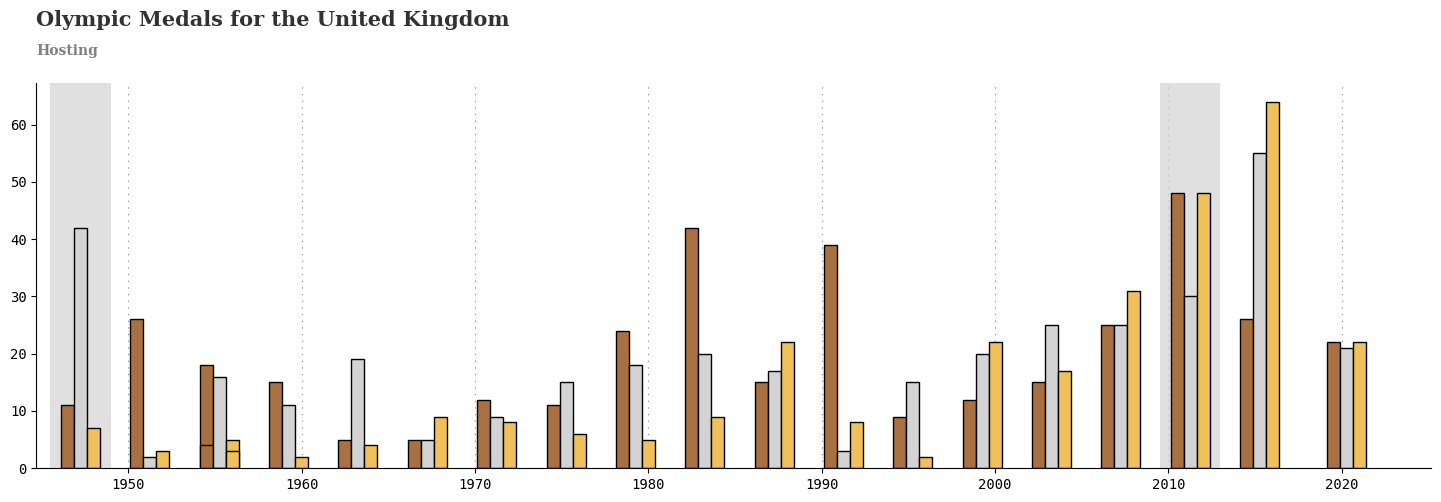

In [42]:
temp = df_new.query("region == 'United Kingdom' & Year > 1945")

fig, ax = plt.subplots(1, 1, figsize=(18, 5))


color = ["#a97142", "lightgray", '#f0c05a']


# Host years
ax.axvspan(1949,1945.5, facecolor='lightgray',alpha=0.7)
ax.axvspan(2013,2009.5, facecolor='lightgray',alpha=0.7)

medals_list = ['Bronze', 'Silver', 'Gold']
width = 0.75
for i, medal in enumerate(np.array(medals_list)):
    ax.bar(temp['Year']+(width*(i-2)), temp[medal], width, color=color[i], label=medal, ec='black')
    
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
    

Xstart, Xend = ax.get_xlim()
Ystart, Yend = ax.get_ylim()

ax.text(Xstart+3,Yend+10, 'Olympic Medals for the United Kingdom', fontsize=15,fontweight='bold',fontfamily='serif',color='#323232')
ax.text(Xstart+3,Yend+5, 'Hosting', fontsize=10,fontweight='bold',fontfamily='serif',color='gray')


ax.set_xlim(Xstart+3, Xend)

ax.grid(which='both', axis='x', zorder=5, color='gray', linestyle=':', dashes=(1,5))

ax.set_axisbelow(True)

plt.show()

For the United Kingdom when it was hosting the 2012 olympics it had as great performance. At the time it was the highest amount of gold medals ever achived by the UK. This was then Surpassed in 2016 Rio olympics though. 

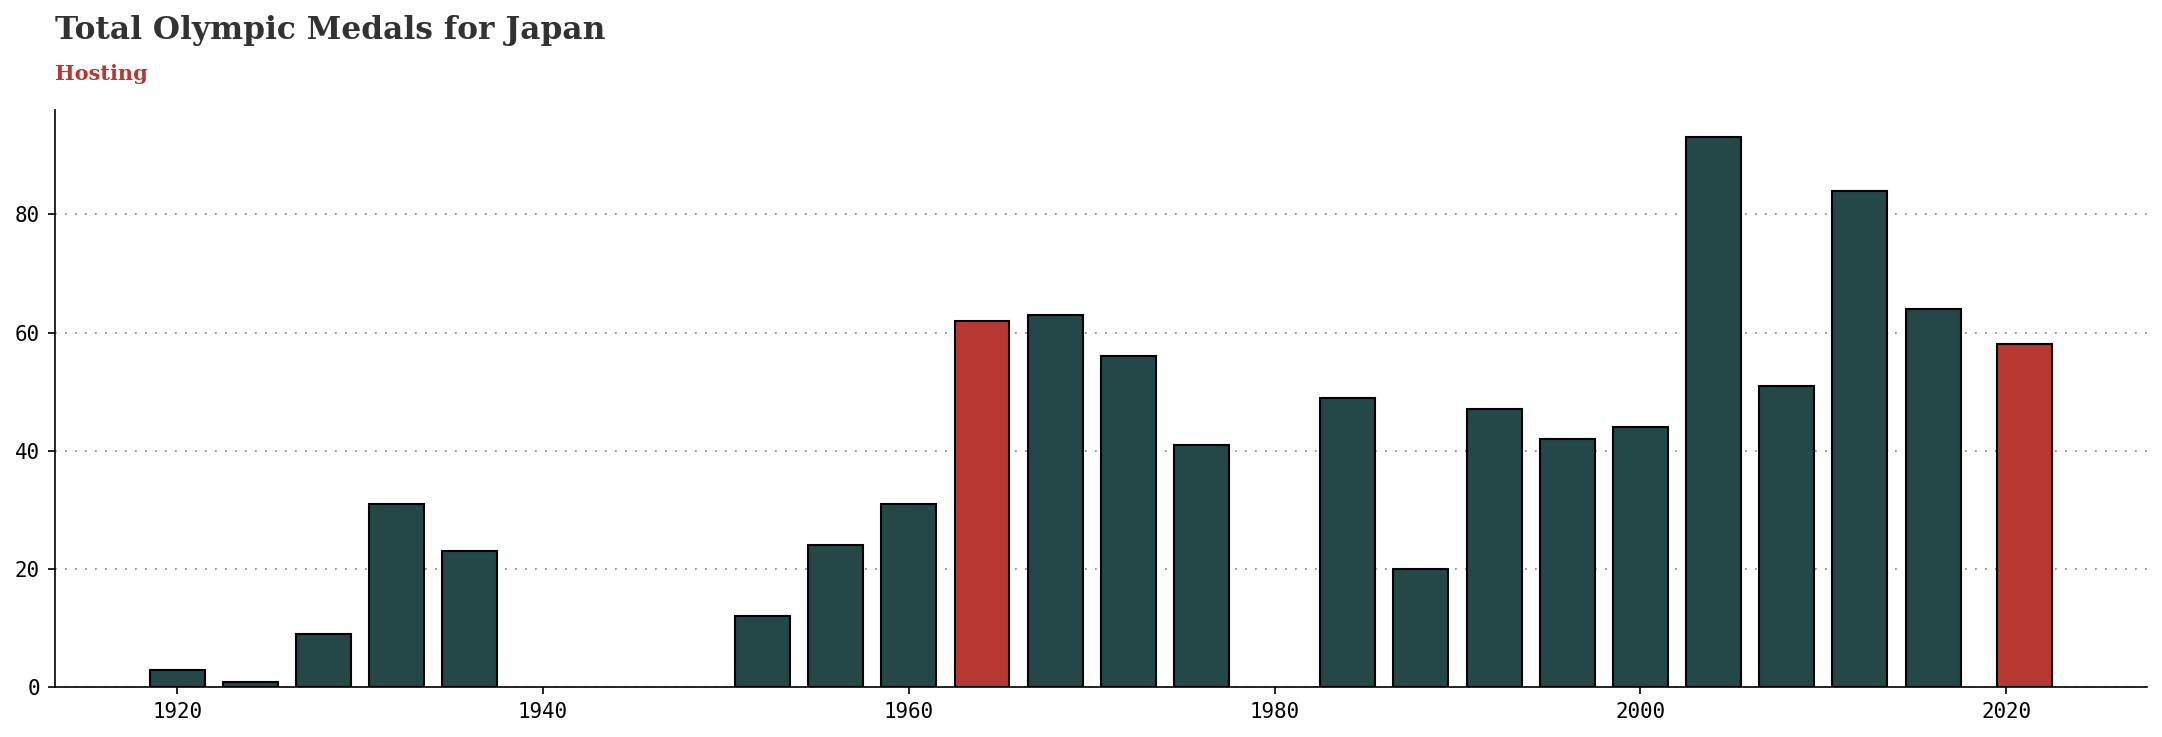

In [43]:
temp = df_new.query("region == 'Japan'")


fig, ax = plt.subplots(1, 1, figsize=(18, 5), dpi=150,)

color = ['#B73832' if i == 1 else '#244747' for i in temp['Is_Host']]

ax.bar(temp['Year'], temp['Total Medals'],width=3, color=color, ec='black')

ax.grid(which='both', axis='y', zorder=5, color='gray', linestyle=':', dashes=(1,5))
ax.set_axisbelow(True)

for s in ['top', 'right']:
    ax.spines[s].set_visible(False)

Xstart, Xend = ax.get_xlim()
Ystart, Yend = ax.get_ylim()

ax.text(Xstart,Yend+12, 'Total Olympic Medals for Japan', fontsize=15,fontweight='bold',fontfamily='serif',color='#323232')
ax.text(Xstart,Yend+5, 'Hosting', fontsize=10,fontweight='bold',fontfamily='serif',color='#B73832')

plt.show()

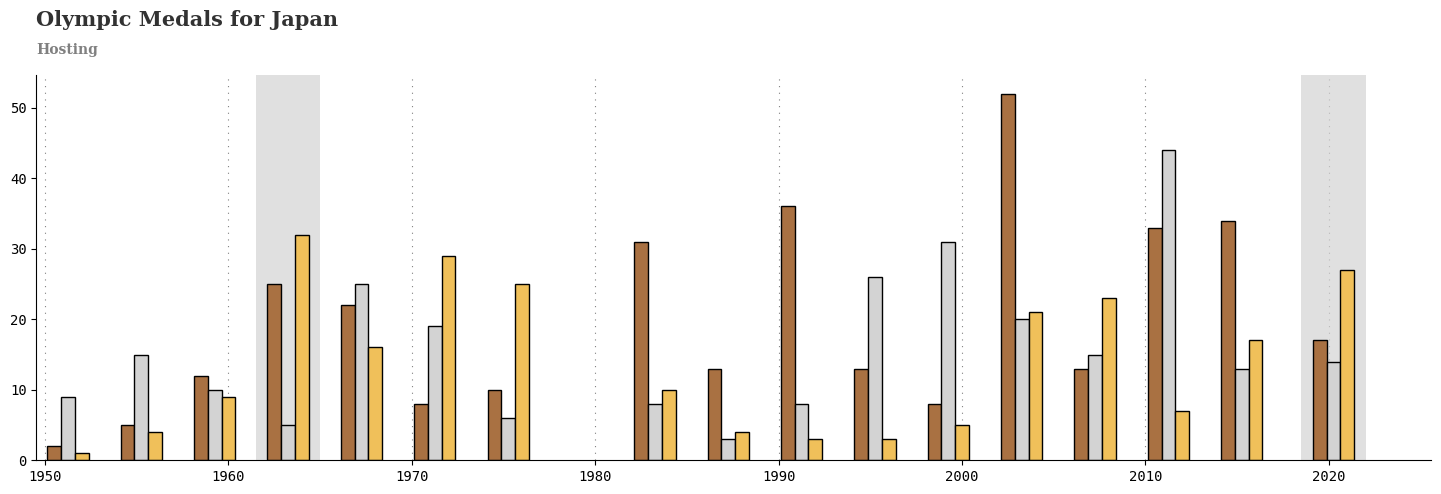

In [44]:

temp = df_new.query("region == 'Japan' & Year > 1945")

fig, ax = plt.subplots(1, 1, figsize=(18, 5),)


color = ["#a97142", "lightgray", '#f0c05a']


# Host years
ax.axvspan(2022,2018.5, facecolor='lightgray',alpha=0.7)
ax.axvspan(1965,1961.5, facecolor='lightgray',alpha=0.7)

medals_list = ['Bronze', 'Silver', 'Gold']
width = 0.75
for i, medal in enumerate(np.array(medals_list)):
    ax.bar(temp['Year']+(width*(i-2)), temp[medal], width, color=color[i], ec='black')
    

Xstart, Xend = ax.get_xlim()
Ystart, Yend = ax.get_ylim()

ax.text(Xstart+3,Yend+7, 'Olympic Medals for Japan', fontsize=15,fontweight='bold',fontfamily='serif',color='#323232')
ax.text(Xstart+3,Yend+3, 'Hosting', fontsize=10,fontweight='bold',fontfamily='serif',color='gray')

ax.set_xlim(Xstart+3, Xend)
ax.grid(which='both', axis='x', zorder=5, color='gray', linestyle=':', dashes=(1,5))
ax.set_axisbelow(True)

for s in ['top', 'right']:
    ax.spines[s].set_visible(False)

plt.show()

For Japan, in the first plot though we can see that the total number of medals is not too extraordinary for Japan. It would rank 4th and 6th all time. But if we look at the total number of gold medals achieved then the times they hosted the summer olympics (1964 and 2021), it would rank 1st and 3rd all time.

## Statistical Testing

Now that we've seen that Hosting the olympic does boost performance, but we will now do some statistical test to see if that assumption is true or not. Using countries who have hosted the olympics, their average medal tallies and gold medals seems to always be higher then usual, but countries hosts olympics very infrequently. Therefore, we must conduct some statistical tests.

In [50]:
dfh = df_new.copy()
dfh["TotalMedals"] = pd.to_numeric(dfh["Total Medals"], errors="coerce")
dfh = dfh.dropna(subset=["region","Year","Is_Host","TotalMedals"]).sort_values(["region","Year"])

In [51]:
def t_ci_mean(x, alpha=0.05):
    """Return mean and 95% CI for 1-sample t."""
    x = pd.Series(x).dropna()
    n  = len(x)
    mu = x.mean()
    sd = x.std(ddof=1)
    se = sd/np.sqrt(n) if n>1 else np.nan
    tcrit = stats.t.ppf(1-alpha/2, df=n-1) if n>1 else np.nan
    lo = mu - tcrit*se if n>1 else np.nan
    hi = mu + tcrit*se if n>1 else np.nan
    return mu, lo, hi, n

def cohens_d_one_sample(x):
    """Cohen's d vs 0."""
    x = pd.Series(x).dropna()
    sd = x.std(ddof=1)
    return x.mean()/sd if sd>0 else np.nan

In [52]:
def uplift_neighbor(df):
    """Host − average(prev, next) for the same country (uses whichever neighbors exist)."""
    rows = []
    for reg, g in df.groupby("region"):
        g = g.sort_values("Year")
        for i in range(len(g)):
            if g.iloc[i]["Is_Host"] == 1:
                neigh = []
                if i-1 >= 0: neigh.append(g.iloc[i-1]["TotalMedals"])
                if i+1 < len(g): neigh.append(g.iloc[i+1]["TotalMedals"])
                if not neigh: 
                    continue
                base = float(np.mean(neigh))
                rows.append({
                    "region": reg, "Year": int(g.iloc[i]["Year"]),
                    "host_total": float(g.iloc[i]["TotalMedals"]),
                    "baseline": base, "uplift": float(g.iloc[i]["TotalMedals"] - base)
                })
    return pd.DataFrame(rows)

In [54]:
def uplift_pre2(df):
    """Host − average of up to the 2 previous Games (pre-only baseline)."""
    rows = []
    for reg, g in df.groupby("region"):
        g = g.sort_values("Year")
        for i in range(len(g)):
            if g.iloc[i]["Is_Host"] == 1:
                prev_vals = g.iloc[max(0, i-2):i]["TotalMedals"].tolist()
                if not prev_vals:
                    continue
                base = float(np.mean(prev_vals))
                rows.append({
                    "region": reg, "Year": int(g.iloc[i]["Year"]),
                    "host_total": float(g.iloc[i]["TotalMedals"]),
                    "baseline": base, "uplift": float(g.iloc[i]["TotalMedals"] - base)
                })
    return pd.DataFrame(rows)

In [55]:
def uplift_alltime(df):
    """Host − mean of all other years for that country (era-mixed, sanity check only)."""
    rows = []
    for reg, g in df.groupby("region"):
        g = g.sort_values("Year")
        for i in range(len(g)):
            if g.iloc[i]["Is_Host"] == 1:
                others = g.drop(g.index[i])["TotalMedals"]
                if len(others) == 0:
                    continue
                base = float(others.mean())
                rows.append({
                    "region": reg, "Year": int(g.iloc[i]["Year"]),
                    "host_total": float(g.iloc[i]["TotalMedals"]),
                    "baseline": base, "uplift": float(g.iloc[i]["TotalMedals"] - base)
                })
    return pd.DataFrame(rows)

In [56]:
def run_tests(tbl, label):
    u = tbl["uplift"].dropna()
    mu, lo, hi, n = t_ci_mean(u)
    t_stat, t_p = stats.ttest_1samp(u, 0.0)              # parametric
    try:
        w_stat, w_p = stats.wilcoxon(u)                  # non-parametric (median vs 0)
    except Exception:
        w_stat, w_p = np.nan, np.nan
    d = cohens_d_one_sample(u)

    return pd.Series({
        "baseline": label,
        "n_hosts": n,
        "mean_uplift": mu,
        "ci_lo": lo,
        "ci_hi": hi,
        "median_uplift": u.median(),
        "t_stat": t_stat, "t_p": t_p,
        "wilcoxon_W": w_stat, "wilcoxon_p": w_p,
        "cohens_d": d
    })

In [57]:
tbl_A = uplift_neighbor(dfh)
tbl_B = uplift_pre2(dfh)
tbl_C = uplift_alltime(dfh)

results = pd.concat([
    run_tests(tbl_A, "Neighbor (prev/next)"),
    run_tests(tbl_B, "Pre-only (last up to 2)"),
    run_tests(tbl_C, "All-time (exclude host)")
], axis=1).T

# Pretty print
display(results.assign(
    mean_uplift=results["mean_uplift"].round(2),
    ci_lo=results["ci_lo"].round(2),
    ci_hi=results["ci_hi"].round(2),
    median_uplift=results["median_uplift"].round(2),
    t_stat=results["t_stat"].round(3),
    t_p=results["t_p"].apply(lambda x: f"{x:.4f}"),
    wilcoxon_W=results["wilcoxon_W"].round(1),
    wilcoxon_p=results["wilcoxon_p"].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "NA"),
    cohens_d=results["cohens_d"].round(2)
)[["baseline","n_hosts","mean_uplift","ci_lo","ci_hi","median_uplift","t_stat","t_p","wilcoxon_W","wilcoxon_p","cohens_d"]])

,baseline,n_hosts,mean_uplift,ci_lo,ci_hi,median_uplift,t_stat,t_p,wilcoxon_W,wilcoxon_p,cohens_d
0,Neighbor (prev/next),30,69.516667,37.616959,101.416375,35.0,4.457017,0.0001,17.0,0.0000,0.813736
1,Pre-only (last up to 2),29,82.017241,46.116802,117.917681,55.0,4.679739,0.0001,23.0,0.0000,0.869006
2,All-time (exclude host),30,76.055598,47.127516,104.98368,45.277778,5.377168,0.0000,15.0,0.0000,0.981732


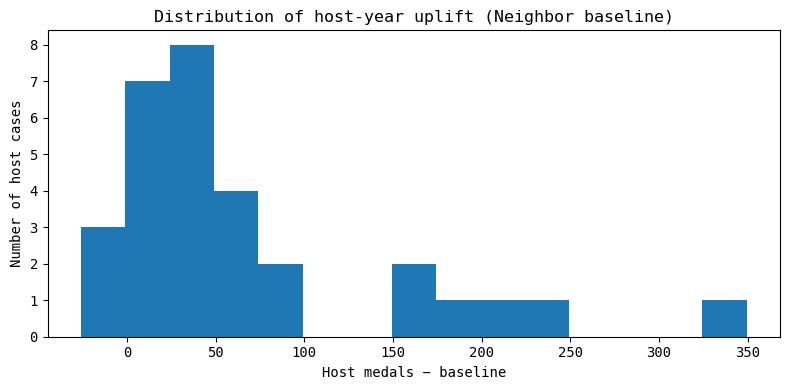

In [59]:
plt.figure(figsize=(8,4))
plt.hist(tbl_A["uplift"].dropna(), bins=15)
plt.title("Distribution of host-year uplift (Neighbor baseline)")
plt.xlabel("Host medals − baseline")
plt.ylabel("Number of host cases")
plt.tight_layout()
plt.show()

## Does Hosting the Olympics Improve Medal Performance?

## Why use multiple baselines?
Using **several reasonable counterfactuals** helps confirm the “host boost” is not an artifact of one specific baseline.  
If uplift is **positive and significant across all baselines**, the finding is **robust**.

---

## Baselines (what each compares the host year against)

### A) Neighbor baseline *(primary)*
**Definition:** Average of the **previous** and **next** Olympics for the **same country**.  
**Benefits**
- **Same-era control:** Reduces distortion from long-run changes (event growth, funding, talent cycles).
- **Within-country pairing:** Cancels country strength; increases statistical power.
- **Balanced trend:** Uses both sides of the host year → less sensitive to one-off spikes/dips.  
**Caveat:** The **next** Olympics may include a “legacy” effect, which can raise the baseline slightly (conservative).

### B) Pre-only baseline *(robustness)*
**Definition:** Average of the **last 1–2 Olympics before** the host year (no future years).  
**Benefits**
- **No post-treatment leakage:** Only uses performance **before** hosting.
- **Causal intuition:** Closer to “what they looked like pre-host.”  
**Caveat:** Fewer past data points for some countries → baseline can be noisier; if the country was already improving, uplift can look **larger** than A.

### C) All-time baseline *(sanity check)*
**Definition:** The country’s **average across all other Olympics** (excluding the host year).  
**Benefits**
- Very **simple** and always available.  
**Caveat:** **Mixes eras** (early vs. modern Games, boycotts, rule changes) → less fair in time; use as secondary evidence only.

---

## What “uplift” means
For each host country-year:
\[
\text{uplift} = \text{medals in host year} - \text{baseline (for same country)}
\]
- **Positive uplift** ⇒ host did better than its own baseline.
- We test whether the **average uplift** across all host cases is **greater than 0**.

---

## Results
- **A) Neighbor baseline (primary):**  
  - **n = 30** host cases  
  - **Mean uplift = +69.5 medals** (95% CI **+37.6 to +101.4**), median **+35.0**  
  - **t-test p = 0.0001**, **Wilcoxon p ≈ 0.0000**, **Cohen’s d = 0.81 (large)**
- **B) Pre-only (last up to 2):**  
  - **n = 29**  
  - **Mean uplift = +82.0 medals** (95% CI **+46.1 to +117.9**), median **+55.0**  
  - **t-test p = 0.0001**, **Wilcoxon p ≈ 0.0000**, **Cohen’s d = 0.87 (large)**
- **C) All-time (exclude host):**  
  - **n = 30**  
  - **Mean uplift = +76.1 medals** (95% CI **+47.1 to +105.0**), median **+45.3**  
  - **t-test p < 0.0001**, **Wilcoxon p ≈ 0.0000**, **Cohen’s d = 0.98 (large)**

**Interpretation:** All three baselines show a **large, statistically significant** host uplift.  
The difference in magnitudes is expected:
- **B ≥ A:** Pre-only avoids future “legacy” and often makes the host year look stronger.
- **C** agrees on direction but mixes eras; keep it as a **sanity check**, not the headline.

---

## What we can conclude from this
> Using within-country, time-local baselines, hosting the Summer Olympics is associated with a **substantial increase in medals** (≈ **+70 to +82** on average) with **tight 95% CIs above zero** and **very small p-values**. The effect is **robust** across multiple baselines.

---